Using device: mps
Loading data from: ./garbage-dataset/Training
Classes in Training: ['paper', 'clothes', 'metal', 'cardboard', 'trash', 'glass', 'biological', 'battery', 'plastic', 'shoes']
Total images: 12259, classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


/Users/vinayak.shenoi/Documents/workspace/waste-recycler/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/vinayak.shenoi/Documents/workspace/waste-recycler/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Class weights: tensor([1.6228, 1.7535, 0.8690, 0.6479, 0.7062, 1.3175, 0.9178, 0.7676, 0.8457,
        2.7077], device='mps:0')
Epoch 0/29
----------
Training Loss: 0.7316 Acc: 0.7698
Validation Loss: 0.3554 Acc: 0.8802

Epoch 1/29
----------
Training Loss: 0.3522 Acc: 0.8863
Validation Loss: 0.3016 Acc: 0.9079

Epoch 2/29
----------
Training Loss: 0.2685 Acc: 0.9147
Validation Loss: 0.2662 Acc: 0.9071

Epoch 3/29
----------
Training Loss: 0.2264 Acc: 0.9235
Validation Loss: 0.2800 Acc: 0.9152

Epoch 4/29
----------
Training Loss: 0.1915 Acc: 0.9379
Validation Loss: 0.2826 Acc: 0.9136

Epoch 5/29
----------
Training Loss: 0.1695 Acc: 0.9421
Validation Loss: 0.2675 Acc: 0.9283

Epoch 6/29
----------
Training Loss: 0.1384 Acc: 0.9526
Validation Loss: 0.2327 Acc: 0.9258

Epoch 7/29
----------
Training Loss: 0.1390 Acc: 0.9538
Validation Loss: 0.2452 Acc: 0.9250

Epoch 8/29
----------
Training Loss: 0.1226 Acc: 0.9547
Validation Loss: 0.3012 Acc: 0.9169

Epoch 9/29
----------
Training Loss

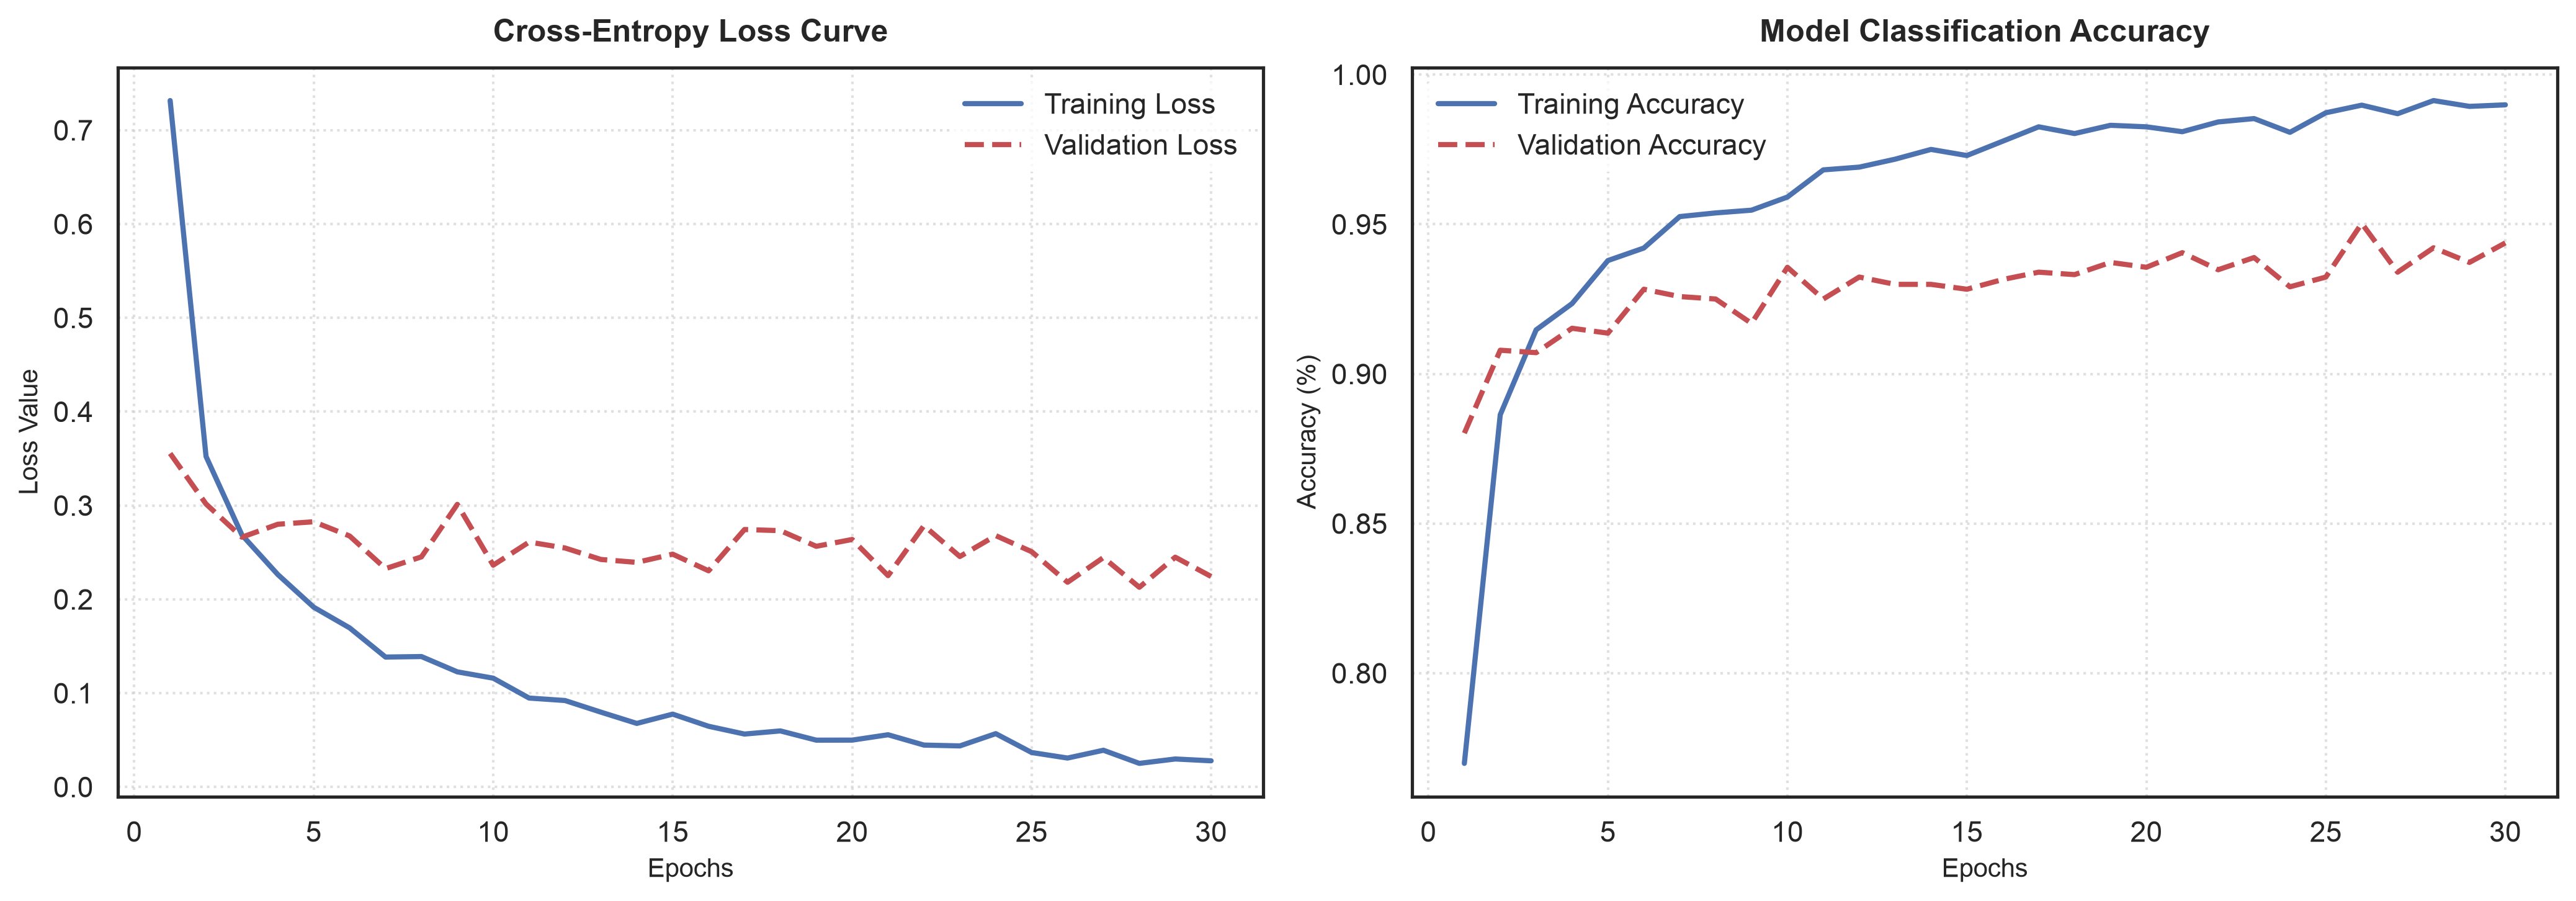

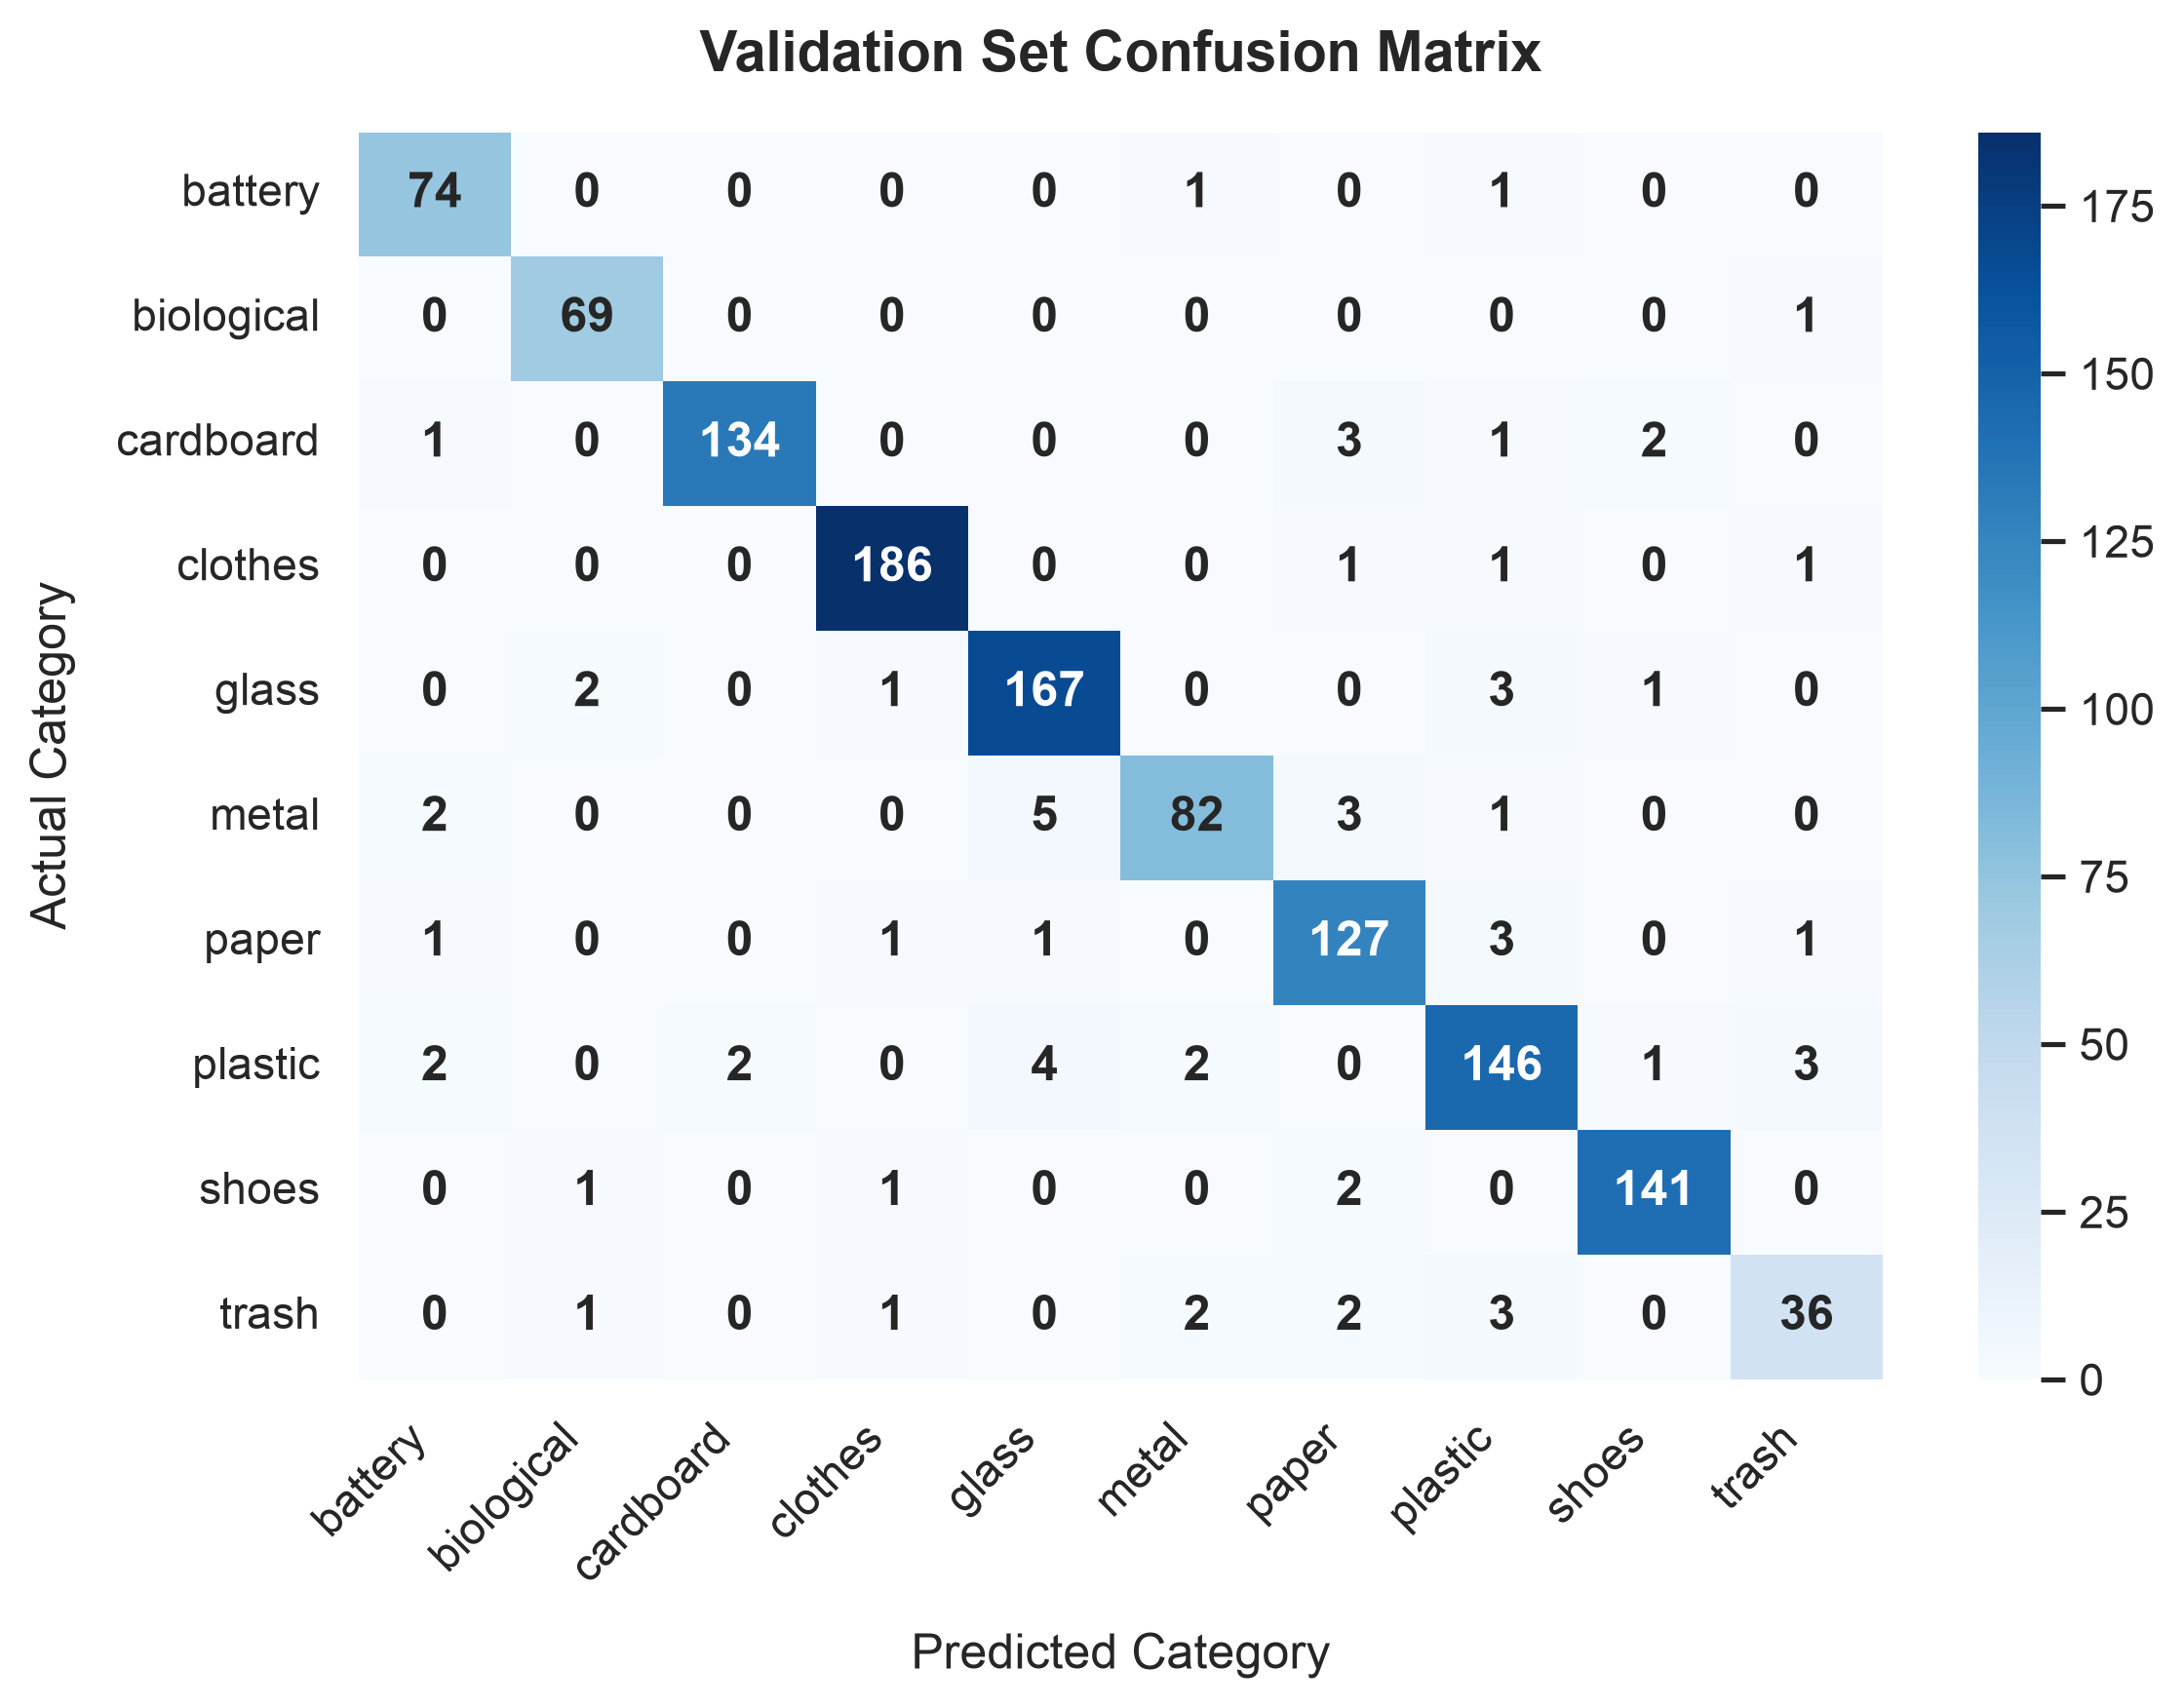


Saving the model...

Model Saved...


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.utils.data import random_split, Subset, SubsetRandomSampler
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

PATH = "model.pth"

### LOADING OUR DATA

# --- IMPROVED: stronger augmentation for training ---
data_transforms = {

    'Training': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)) # Add this here
    ]),
    'Testing': transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    ])
}

path = './garbage-dataset'
data_dir = path

# --- FIX: point ImageFolder to the subfolder that contains the actual class folders ---
# 'garbage-dataset/' has subdirs: original, Testing, Training
# Each of those contains the 10 class subfolders (battery, biological, ...)
# We load from 'Training' which has the 10 classes, then split into train/val/test
data_dir = os.path.join(path, 'Training')
print(f"Loading data from: {data_dir}")
print(f"Classes in Training: {os.listdir(data_dir)}")

all_image_datasets = datasets.ImageFolder(data_dir, data_transforms['Training'])
print(f"Total images: {len(all_image_datasets)}, classes: {all_image_datasets.classes}")

all_training_datasets = {}
all_validation_datasets = {}
all_testing_datasets = {}

# --- IMPROVED: stratified split instead of random_split ---
# Build per-class index lists
class_indices = {}
for idx, (_, label) in enumerate(all_image_datasets):
    class_indices.setdefault(label, []).append(idx)

train_idx, val_idx, test_idx = [], [], []
for indices in class_indices.values():
    np.random.shuffle(indices)
    n = len(indices)
    train_idx.extend(indices[:int(0.8 * n)])
    val_idx.extend(indices[int(0.8 * n):int(0.9 * n)])
    test_idx.extend(indices[int(0.9 * n):])

training_dataset = Subset(all_image_datasets, train_idx)
validation_dataset = Subset(all_image_datasets, val_idx)
testing_dataset = Subset(all_image_datasets, test_idx)

# Apply validation/testing transforms
for ds in [validation_dataset, testing_dataset]:
    ds.transform = data_transforms['Testing']

# --- IMPROVED: batch_size=64, num_workers=0 (MPS compatibility) ---
trainingdataloaders = torch.utils.data.DataLoader(
    training_dataset, batch_size=64, shuffle=True, num_workers=0)
validationdataloaders = torch.utils.data.DataLoader(
    validation_dataset, batch_size=64, shuffle=False, num_workers=0)
testingdataloaders = torch.utils.data.DataLoader(
    testing_dataset, batch_size=64, shuffle=False, num_workers=0)

dataloaders = {
    'Training': trainingdataloaders,
    'Validation': validationdataloaders,
    'Testing': testingdataloaders
}

dataset_sizes = {'Training': len(training_dataset), 'Validation': len(validation_dataset), 'Testing': len(testing_dataset)}
class_names = all_image_datasets.classes

### Training our model

def train_model(model, criterion, optimizer, scheduler, num_epochs=30):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # NEW: accumulate per-epoch metrics for plotting
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['Training', 'Validation']:
            if phase == 'Training':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'Training'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'Training':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'Training':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = float(running_corrects.float()) / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # NEW: append metrics for plotting
            if phase == 'Training':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc)

            # deep copy the model
            if phase == 'Validation' and epoch_acc > best_acc:
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), './best-model-checkpoint.pt')
                best_acc = epoch_acc

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)

    # NEW: return metrics alongside model
    return model, train_losses, val_losses, train_accs, val_accs

# --- IMPROVED: ResNet-50 instead of ResNet-18 ---
model_ft = models.resnet50(pretrained=True)

# FREEZE ALL LAYERS FIRST
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze just the final residual block (Layer 4) so it can adapt to garbage shapes
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# Redefine the final layer (this will automatically have requires_grad=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, len(class_names))
)

model_ft = model_ft.to(device)

# --- IMPROVED: compute class weights dynamically from actual data ---
# Count images per class in the training dataset
from collections import Counter
train_labels = [label for _, label in training_dataset]
class_counts = Counter(train_labels)

# Build weight tensor with length = len(class_names) (dynamically)
# Weight = total_samples / (num_classes * class_count)
total = sum(class_counts.values())
num_classes = len(class_names)
class_weights = torch.tensor(
    [total / (num_classes * class_counts.get(i, 1)) for i in range(num_classes)],
    dtype=torch.float32).to(device)

print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

# --- IMPROVED: AdamW with lower LR + weight decay ---
optimizer_ft = optim.AdamW(model_ft.parameters(), lr=1e-4, weight_decay=0.05)

# --- IMPROVED: CosineAnnealingWarmRestarts instead of StepLR ---
# Decays smoothly over all 50 epochs without resetting
exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=50, eta_min=1e-6
)

# --- IMPROVED: 50 epochs instead of 15 ---
model_ft, train_losses, val_losses, train_accs, val_accs = train_model(
    model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=30)

# --- PLOTTING: Training History ---
plot_training_history(train_losses, val_losses, train_accs, val_accs)


# --- PLOTTING: Confusion Matrix ---
# Collect predictions on validation set
model_ft.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for inputs, labels in validationdataloaders:
        outputs = model_ft(inputs.to(device))
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

plot_paper_confusion_matrix(all_labels, all_preds, class_names)

# torch.save(model_ft.state_dict(), '../input/brain-tumor-classification-mri/my2epochmodel.pt')
def plot_paper_confusion_matrix(y_true, y_pred, classes):
    """
    Generates a publication-grade confusion matrix.
    y_true: list/array of true class indices
    y_pred: list/array of predicted class indices
    classes: list of strings (class_names from dataset)
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6), dpi=300) # High DPI for paper clarity
    sns.set_theme(style="white")

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=classes, yticklabels=classes,
                annot_kws={"size": 12, "weight": "bold"})

    plt.title('Validation Set Confusion Matrix', fontsize=14, pad=15, weight='bold')
    plt.ylabel('Actual Category', fontsize=12, labelpad=10)
    plt.xlabel('Predicted Category', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save directly to include in your paper directory
    plt.savefig('garbage_confusion_matrix.png', bbox_inches='tight')
    plt.show()

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    """
    Plots professional, side-by-side subplots for Loss and Accuracy metrics.
    """
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

    # Left Plot: Loss Curves
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r--', label='Validation Loss', linewidth=2)
    ax1.set_title('Cross-Entropy Loss Curve', fontsize=12, weight='bold', pad=10)
    ax1.set_xlabel('Epochs', fontsize=10)
    ax1.set_ylabel('Loss Value', fontsize=10)
    ax1.legend(frameon=True, facecolor='white', edgecolor='none')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Right Plot: Accuracy Curves
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'r--', label='Validation Accuracy', linewidth=2)
    ax2.set_title('Model Classification Accuracy', fontsize=12, weight='bold', pad=10)
    ax2.set_xlabel('Epochs', fontsize=10)
    ax2.set_ylabel('Accuracy (%)', fontsize=10)
    ax2.legend(frameon=True, facecolor='white', edgecolor='none')
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('training_performance_curves.png', bbox_inches='tight')
    plt.show()
print("\nSaving the model...")
torch.save(model_ft.state_dict(), "model.pth")
print("\nModel Saved...")